## Librerias y cuda
Descarga de roboflow directo no funciono, lo termine importando.<br>
Estructurea - folder structure - tenemos que separarlo

In [1]:
import os, random, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## Hiperparametros

In [5]:
DATA_DIR    = Path("/home/sagemaker-user/upp/train")
NUM_EPOCHS  = 50
BATCH_SIZE  = 32
LR          = 1e-3
IMG_SIZE    = 224
NUM_WORKERS = 8
SEED        = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

## Transformar imagenes a formato estandar para entrenamiento

In [8]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),    
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

## Split dataset

In [9]:
from torch.utils.data import random_split

full_ds = datasets.ImageFolder(DATA_DIR, transform=train_tf)

val_size   = int(0.2 * len(full_ds))
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))

# Apply val transforms to the val split
val_ds.dataset.transform = val_tf

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True)

/home/sagemaker-user/.conda/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
NUM_CLASSES = len(full_ds.classes)
print(f"Classes ({NUM_CLASSES}): {full_ds.classes}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Classes (4): ['stage1', 'stage2', 'stage3', 'stage4']
Train: 3851 | Val: 962


## Train model

In [24]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

In [25]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [26]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_epoch = 0.0, 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_dl,   criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc, best_epoch = vl_acc, epoch
        torch.save(model.state_dict(), "/home/sagemaker-user/upp/best_model_upp.pth")

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"Val loss {vl_loss:.4f} acc {vl_acc:.4f} | "
          f"LR {scheduler.get_last_lr()[0]:.2e} | {time.time()-t0:.1f}s")

print(f"\nBest val acc: {best_val_acc:.4f} at epoch {best_epoch}")

Epoch 01/50 | Train loss 0.7748 acc 0.7790 | Val loss 0.6351 acc 0.8805 | LR 9.99e-04 | 14.7s


Epoch 02/50 | Train loss 0.5498 acc 0.9031 | Val loss 0.5216 acc 0.9231 | LR 9.96e-04 | 14.1s


Epoch 03/50 | Train loss 0.4863 acc 0.9418 | Val loss 0.4633 acc 0.9626 | LR 9.91e-04 | 14.6s


Epoch 04/50 | Train loss 0.4379 acc 0.9649 | Val loss 0.4405 acc 0.9719 | LR 9.84e-04 | 15.0s


Epoch 05/50 | Train loss 0.4123 acc 0.9795 | Val loss 0.4435 acc 0.9667 | LR 9.76e-04 | 14.5s


...

Epoch 46/50 | Train loss 0.3499 acc 1.0000 | Val loss 0.3761 acc 0.9906 | LR 1.57e-05 | 13.9s


Epoch 47/50 | Train loss 0.3499 acc 1.0000 | Val loss 0.3750 acc 0.9896 | LR 8.86e-06 | 13.6s


Epoch 48/50 | Train loss 0.3505 acc 0.9997 | Val loss 0.3739 acc 0.9906 | LR 3.94e-06 | 13.6s


Epoch 49/50 | Train loss 0.3499 acc 1.0000 | Val loss 0.3782 acc 0.9875 | LR 9.87e-07 | 14.1s


Epoch 50/50 | Train loss 0.3502 acc 0.9997 | Val loss 0.3748 acc 0.9896 | LR 0.00e+00 | 13.6s

Best val acc: 0.9906 at epoch 38


## Evaluar modelo

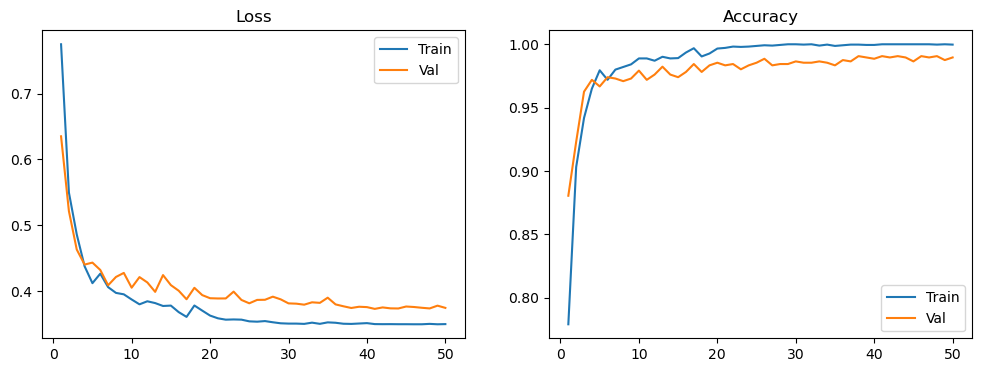

In [27]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()


              precision    recall  f1-score   support

      stage1       1.00      1.00      1.00       226
      stage2       0.98      1.00      0.99       246
      stage3       0.99      0.98      0.98       246
      stage4       1.00      1.00      1.00       244

    accuracy                           0.99       962
   macro avg       0.99      0.99      0.99       962
weighted avg       0.99      0.99      0.99       962



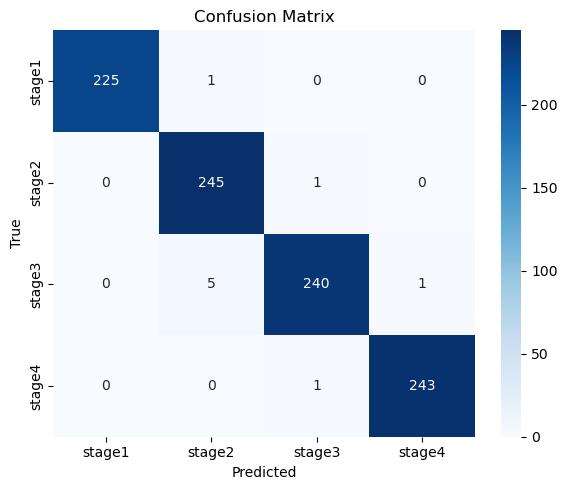

In [28]:
model.load_state_dict(torch.load("/home/sagemaker-user/upp/best_model_upp.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_dl:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("\n" + classification_report(all_labels, all_preds, target_names=full_ds.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(max(6, NUM_CLASSES), max(5, NUM_CLASSES - 1)))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=full_ds.classes, yticklabels=full_ds.classes)
plt.ylabel("True"); plt.xlabel("Predicted")
plt.title("Confusion Matrix"); plt.tight_layout()

## Guardar modelo

In [29]:
model.load_state_dict(torch.load("/home/sagemaker-user/upp/best_model_upp.pth", map_location=DEVICE))
model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
scripted_model = torch.jit.trace(model, dummy_input)
scripted_model.save("./model_scripted_upp.pt")

# Also save class names — needed for inference
import json
with open("./classes.json", "w") as f:
    json.dump(full_ds.classes, f)

print("Exported model and classes.")

Exported model and classes.


## Out-of-Domain (OOD) Detection

Reduces false positives by rejecting images that are visually dissimilar to the
training wound images before the classifier ever runs.

**Strategy**
1. Embed every training image with `Qdrant/clip-ViT-B-32-vision` (via `fastembed`).
2. At inference, embed the query image and compute its **mean top-K cosine similarity**
   to the training index (a "proximity score").
3. A threshold calibrated on the validation set (targeting ≥ 95 % recall on real
   wound images) gates the classifier: images below the threshold are flagged OOD
   and no class prediction is returned.

In [2]:
# Install once
!pip install fastembed --quiet

In [3]:
import os, json, numpy as np
from pathlib import Path
from fastembed import ImageEmbedding
from tqdm import tqdm

# ── OOD hyper-parameters ──────────────────────────────────────────────────────
OOD_INDEX_PATH    = "/home/sagemaker-user/upp/ood_index.npy"
OOD_CONFIG_PATH   = "/home/sagemaker-user/upp/ood_config.json"
OOD_MODEL_NAME    = "Qdrant/clip-ViT-B-32-vision"
OOD_BATCH_SIZE    = 64    # images per fastembed call
OOD_TOP_K         = 10    # neighbours for proximity score
OOD_TARGET_RECALL = 0.95  # fraction of val in-domain images that must pass

/home/sagemaker-user/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-26 01:46:15.709902359 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [6]:
clip_model = ImageEmbedding(model_name=OOD_MODEL_NAME)

def collect_image_paths(root: Path) -> list:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted(str(p) for p in root.rglob("*") if p.suffix.lower() in exts)

def embed_images(paths: list, model, batch_size: int = 64):
    """Returns (N, D) float32 array of L2-normalised CLIP embeddings."""
    all_embs = []
    for i in tqdm(range(0, len(paths), batch_size), desc="Embedding"):
        batch = paths[i : i + batch_size]
        all_embs.extend(list(model.embed(batch)))
    return np.array(all_embs, dtype=np.float32)

print("Building OOD index from training images …")
train_paths = collect_image_paths(DATA_DIR)   # DATA_DIR defined in Hyperparameters cell
print(f"  Found {len(train_paths)} images")

train_embeddings = embed_images(train_paths, clip_model, OOD_BATCH_SIZE)
np.save(OOD_INDEX_PATH, train_embeddings)
print(f"  Saved → {OOD_INDEX_PATH}  shape={train_embeddings.shape}")

Building OOD index from training images …
  Found 4813 images


Embedding: 100%|██████████| 76/76 [05:27<00:00,  4.30s/it]

  Saved → /home/sagemaker-user/upp/ood_index.npy  shape=(4813, 512)


Scoring 962 validation images …


100%|██████████| 962/962 [01:53<00:00,  8.50it/s]



Calibration results
  Threshold        : 0.9220
  Val images kept  : 94.91%  (target 95%)


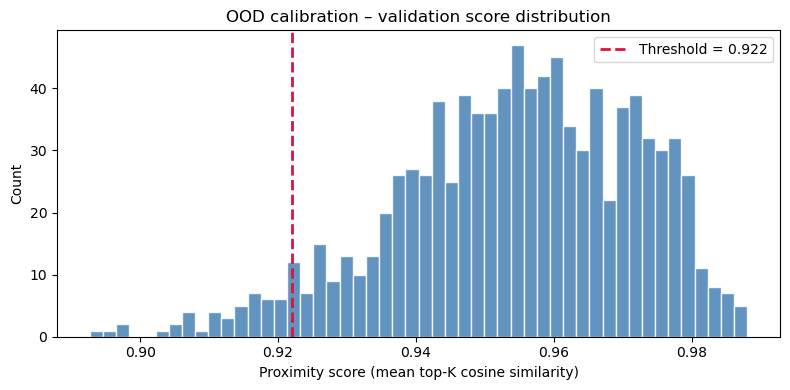

Saved OOD config → /home/sagemaker-user/upp/ood_config.json


In [11]:
# ── Calibrate threshold on validation set ────────────────────────────────────
val_indices   = val_ds.indices
val_img_paths = [full_ds.imgs[i][0] for i in val_indices]

print(f"Scoring {len(val_img_paths)} validation images …")
val_scores = []
for path in tqdm(val_img_paths):
    q    = np.array(list(clip_model.embed([path]))[0], dtype=np.float32)
    sims = train_embeddings @ q
    top_k = np.partition(sims, -OOD_TOP_K)[-OOD_TOP_K:]
    val_scores.append(float(top_k.mean()))

val_scores = np.array(val_scores)

# Threshold at the (1 - target_recall) percentile of val scores
threshold = float(np.percentile(val_scores, (1 - OOD_TARGET_RECALL) * 100))
print(f"\nCalibration results")
print(f"  Threshold        : {threshold:.4f}")
print(f"  Val images kept  : {(val_scores >= threshold).mean():.2%}  "
      f"(target {OOD_TARGET_RECALL:.0%})")

# ── Visualise ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(val_scores, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(threshold, color="crimson", lw=2, linestyle="--",
            label=f"Threshold = {threshold:.3f}")
plt.xlabel("Proximity score (mean top-K cosine similarity)")
plt.ylabel("Count")
plt.title("OOD calibration – validation score distribution")
plt.legend(); plt.tight_layout(); plt.show()

# ── Save config ───────────────────────────────────────────────────────────────
ood_config = {
    "threshold"    : threshold,
    "k"            : OOD_TOP_K,
    "target_recall": OOD_TARGET_RECALL,
    "model"        : OOD_MODEL_NAME,
}
with open(OOD_CONFIG_PATH, "w") as f:
    json.dump(ood_config, f, indent=2)
print(f"Saved OOD config → {OOD_CONFIG_PATH}")

In [12]:
class OODDetector:
    """
    K-nearest-neighbour OOD detector using CLIP embeddings.

    Parameters
    ----------
    index_path  : path to .npy file produced by the indexing cell
    config_path : path to JSON written by the calibration cell
    """
    def __init__(self, index_path: str, config_path: str,
                 model_name: str = OOD_MODEL_NAME):
        self.index = np.load(index_path)          # (N, D) L2-normalised
        with open(config_path) as f:
            cfg = json.load(f)
        self.threshold = cfg["threshold"]
        self.k         = cfg["k"]
        self._model    = ImageEmbedding(model_name=model_name)

    def _embed(self, image_path: str) -> np.ndarray:
        return np.array(list(self._model.embed([image_path]))[0], dtype=np.float32)

    def proximity_score(self, image_path: str) -> float:
        """Mean cosine similarity to the K nearest training neighbours."""
        q     = self._embed(image_path)
        sims  = self.index @ q
        top_k = np.partition(sims, -self.k)[-self.k:]
        return float(top_k.mean())

    def is_out_of_domain(self, image_path: str) -> bool:
        return self.proximity_score(image_path) < self.threshold

detector = OODDetector(OOD_INDEX_PATH, OOD_CONFIG_PATH)
print("OODDetector ready. Threshold:", detector.threshold)

OODDetector ready. Threshold: 0.9219675779342651


In [13]:
import torch
from torchvision import transforms
from PIL import Image

infer_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

with open("./classes.json") as f:
    CLASS_NAMES = json.load(f)

scripted_model = torch.jit.load("./model_scripted_upp.pt", map_location=DEVICE)
scripted_model.eval()


def predict(image_path: str) -> dict:
    """
    Full inference with OOD gate.

    Returns
    -------
    {
        "ood"       : bool,
        "label"     : str | None,     # None when OOD
        "confidence": float | None,   # None when OOD
        "proximity" : float,          # always present
    }
    """
    proximity = detector.proximity_score(image_path)

    if proximity < detector.threshold:
        return {"ood": True, "label": None, "confidence": None,
                "proximity": proximity}

    img    = Image.open(image_path).convert("RGB")
    tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(scripted_model(tensor), dim=1).squeeze()
    idx = probs.argmax().item()
    return {
        "ood"       : False,
        "label"     : CLASS_NAMES[idx],
        "confidence": float(probs[idx]),
        "proximity" : proximity,
    }


# ── Smoke test ─────────────────────────────────────────────────────────────────
sample = val_img_paths[0]
print(f"Wound image result : {predict(sample)}")
# For OOD test, swap in any non-wound photo path:
# print(predict("/path/to/random_non_wound.jpg"))

Wound image result : {'ood': False, 'label': 'stage1', 'confidence': 0.9193881750106812, 'proximity': 0.9586954116821289}


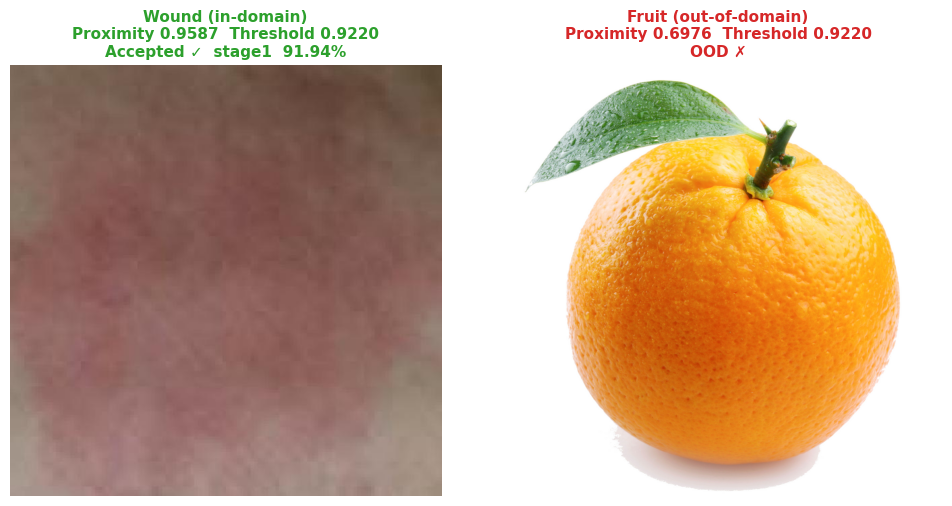

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

FRUIT_IMAGE_PATH = "/home/sagemaker-user/upp/orange.jpg"  # ← change if needed

wound_path = val_img_paths[0]
test_cases = [
    ("Wound (in-domain)",    wound_path),
    ("Fruit (out-of-domain)", FRUIT_IMAGE_PATH),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (title, path) in zip(axes, test_cases):
    result    = predict(path)
    proximity = result["proximity"]
    is_ood    = result["ood"]

    color = "#d62728" if is_ood else "#2ca02c"

    ax.imshow(Image.open(path).convert("RGB")); ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(6); spine.set_visible(True)

    status = "OOD ✗" if is_ood else f"Accepted ✓  {result['label']}  {result['confidence']:.2%}"
    ax.set_title(f"{title}\nProximity {proximity:.4f}  Threshold {detector.threshold:.4f}\n{status}",
                 fontsize=11, color=color, fontweight="bold")

plt.tight_layout(); plt.show()